# Time Series Data Visualization - ETTh1 Dataset
## Comprehensive analysis and visualization of hourly electricity load data

### 1. Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Load data
df = pd.read_csv('ETT-small/ETTh1.csv')
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nData info:")
print(df.info())
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (17420, 7)

First few rows:
                      HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
date                                                                    
2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001
2016-07-01 03:00:00  5.090  1.942  1.279  0.391  3.807  1.279  25.044001
2016-07-01 04:00:00  5.358  1.942  1.492  0.462  3.868  1.279  21.948000

Data info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17420 entries, 2016-07-01 00:00:00 to 2018-06-26 19:00:00
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   HUFL    17420 non-null  float64
 1   HULL    17420 non-null  float64
 2   MUFL    17420 non-null  float64
 3   MULL    17420 non-null  float64
 4   LUFL    17420 non-null  float64
 5   LULL    17420 non-null  flo

### 2. Time Series Overview Plot

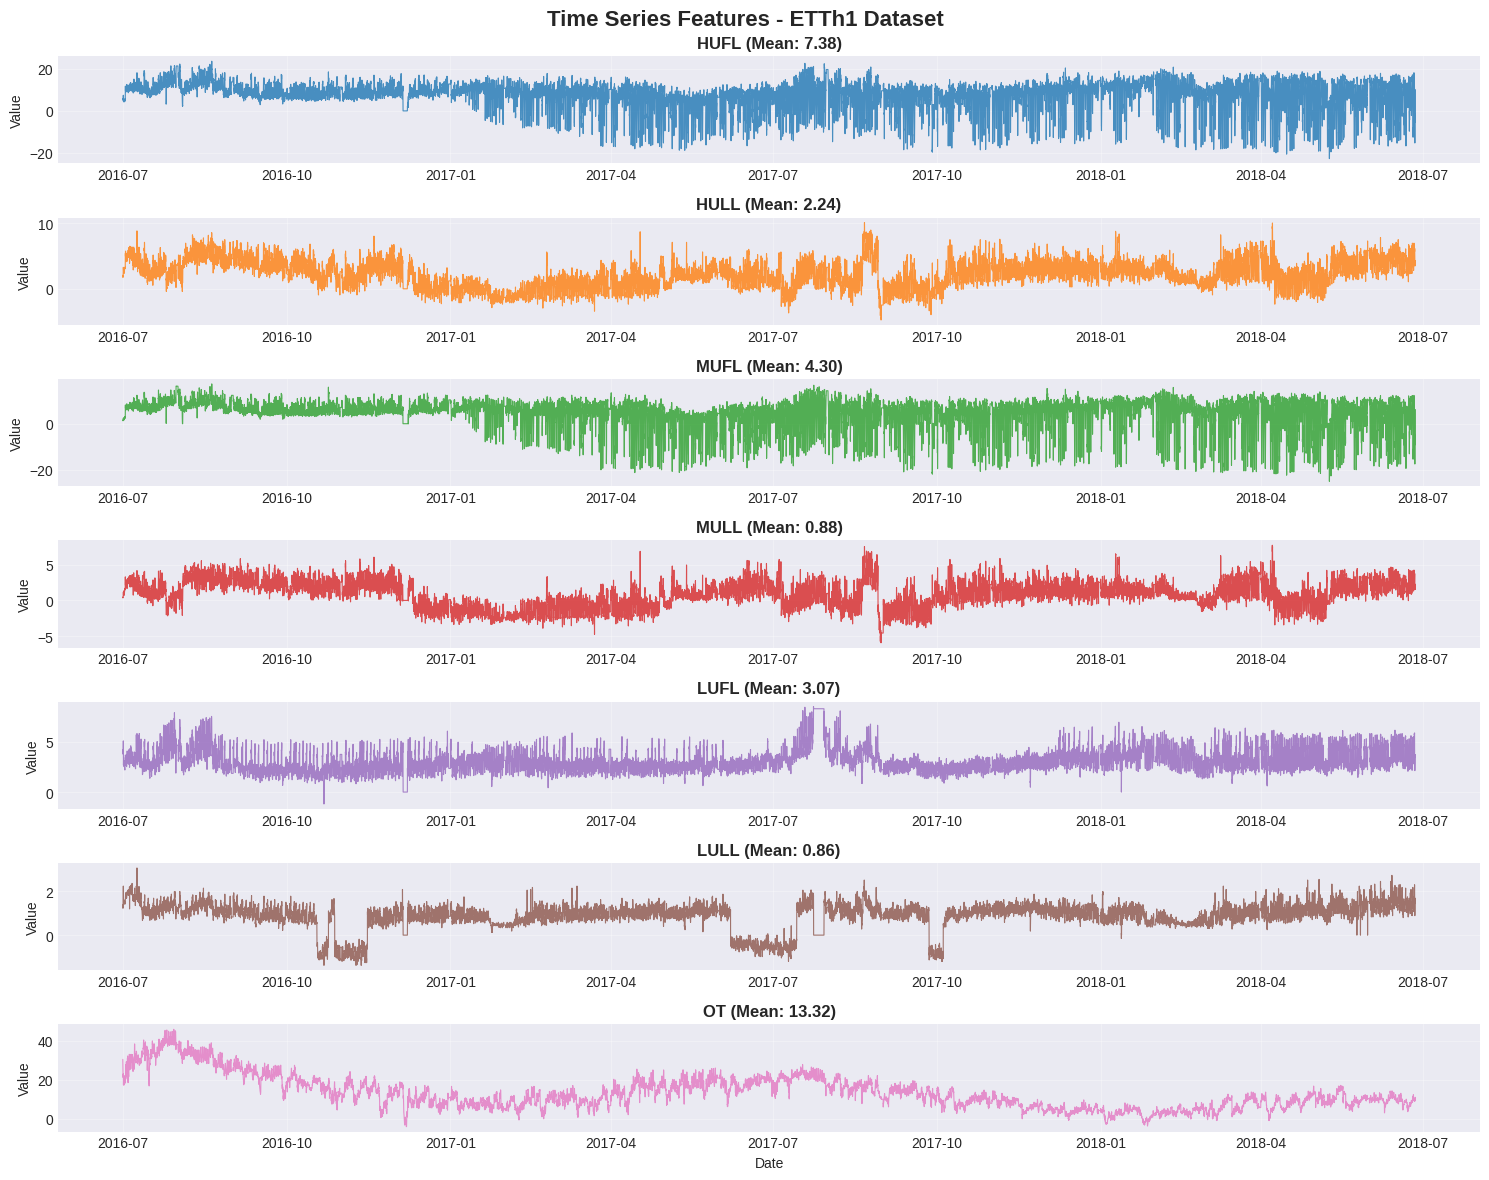

In [2]:
# Plot all features
fig, axes = plt.subplots(7, 1, figsize=(15, 12))
fig.suptitle('Time Series Features - ETTh1 Dataset', fontsize=16, fontweight='bold')

for idx, col in enumerate(df.columns):
    axes[idx].plot(df.index, df[col], color=plt.cm.tab10(idx), linewidth=0.8, alpha=0.8)
    axes[idx].set_title(f'{col} (Mean: {df[col].mean():.2f})', fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
fig.tight_layout()
plt.show()

### 3. Distribution Analysis

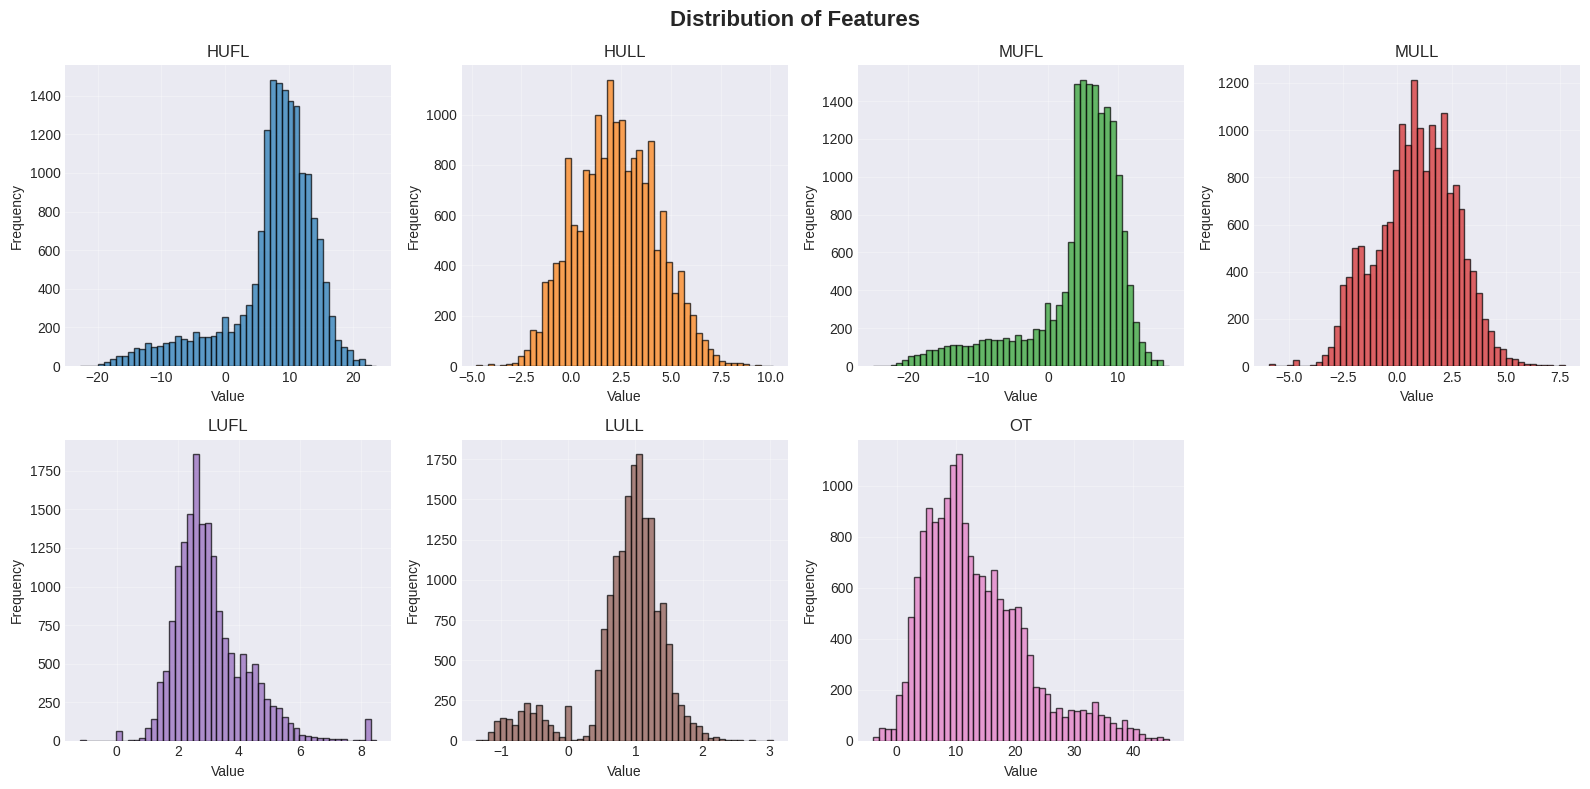

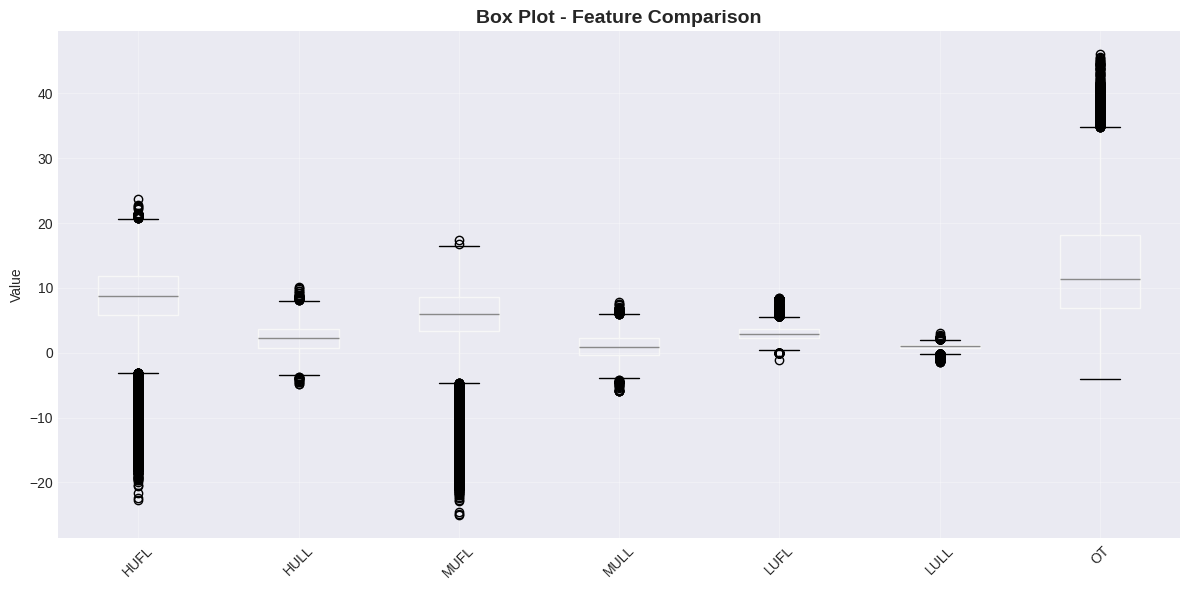

In [3]:
# Distribution plot for all features
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribution of Features', fontsize=16, fontweight='bold')
axes = axes.flatten()

for idx, col in enumerate(df.columns):
    axes[idx].hist(df[col], bins=50, color=plt.cm.tab10(idx), alpha=0.7, edgecolor='black')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(True, alpha=0.3)

# Hide the extra subplot
axes[-1].set_visible(False)
fig.tight_layout()
plt.show()

# Box plot comparison
fig, ax = plt.subplots(figsize=(12, 6))
df.boxplot(ax=ax)
ax.set_title('Box Plot - Feature Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Value')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

### 4. Correlation Analysis

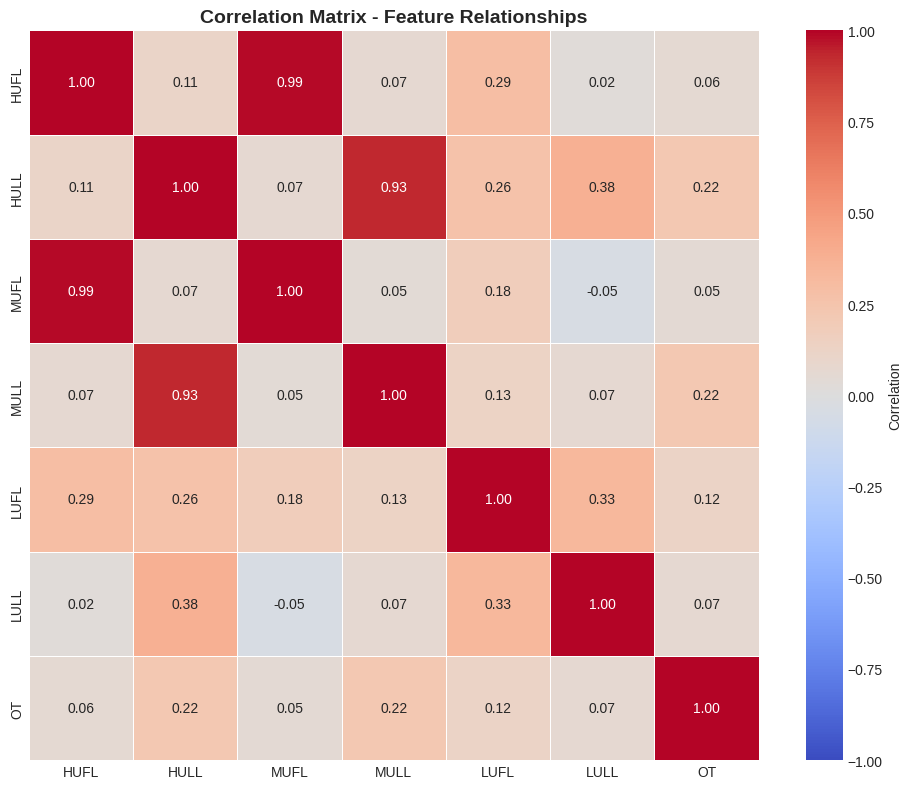


Correlation with OT (Target):
OT      1.000000
HULL    0.224354
MULL    0.220004
LUFL    0.118836
LULL    0.067455
HUFL    0.059916
MUFL    0.050854
Name: OT, dtype: float64


In [4]:
# Correlation matrix
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, ax=ax, cbar_kws={'label': 'Correlation'}, 
            vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Correlation Matrix - Feature Relationships', fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

# Print correlation with target (OT)
print("\nCorrelation with OT (Target):")
print(corr_matrix['OT'].sort_values(ascending=False))

### 5. Seasonal Decomposition (for OT feature)

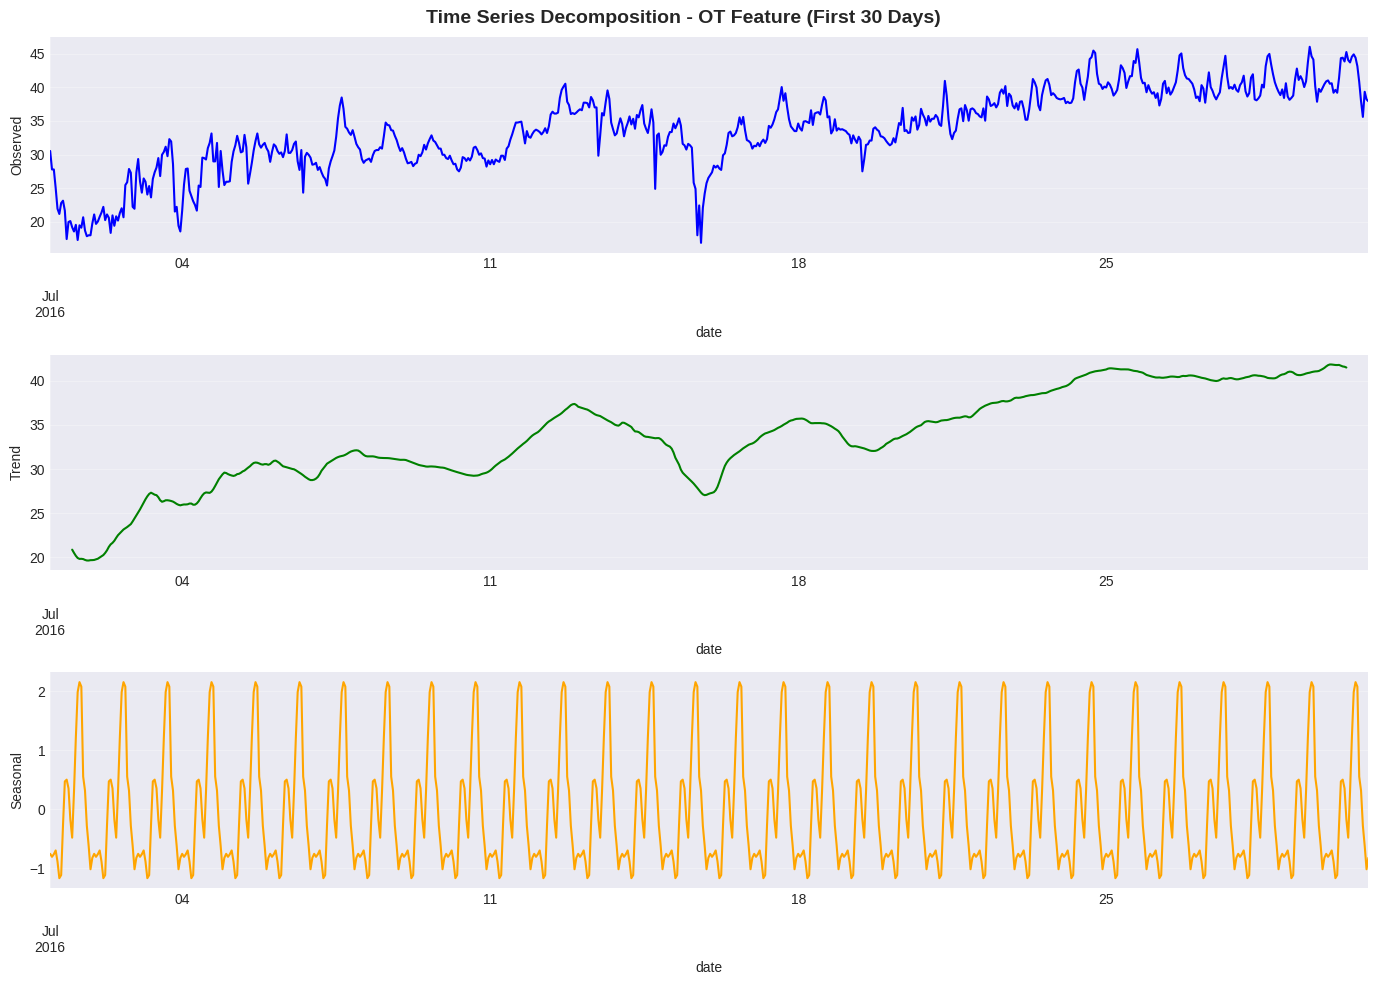

In [5]:
# Seasonal decomposition (using a sample for efficiency)
# Using period = 24 for hourly data (daily cycle)
sample_data = df['OT'].iloc[:720]  # First 30 days

decomposition = seasonal_decompose(sample_data, model='additive', period=24)

fig, axes = plt.subplots(3, 1, figsize=(14, 10))
fig.suptitle('Time Series Decomposition - OT Feature (First 30 Days)', fontsize=14, fontweight='bold')

decomposition.observed.plot(ax=axes[0], color='blue')
axes[0].set_ylabel('Observed')
axes[0].grid(True, alpha=0.3)

decomposition.trend.plot(ax=axes[1], color='green')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

decomposition.seasonal.plot(ax=axes[2], color='orange')
axes[2].set_ylabel('Seasonal')
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

### 6. Autocorrelation Analysis (ACF/PACF)

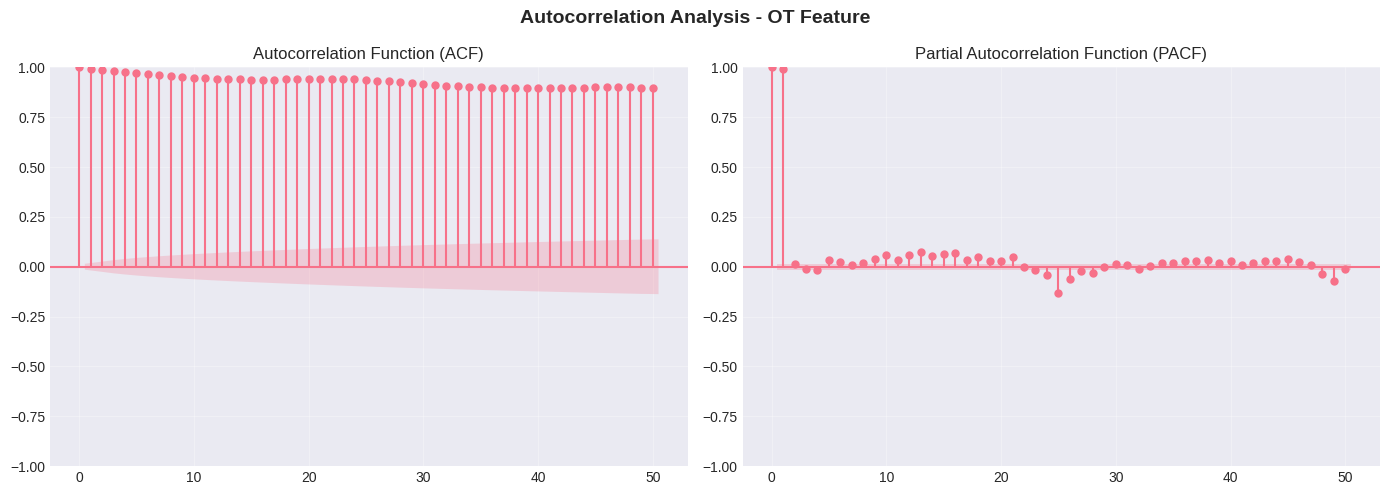

In [6]:
# ACF plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Autocorrelation Analysis - OT Feature', fontsize=14, fontweight='bold')

# ACF
plot_acf(df['OT'].dropna(), lags=50, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')
axes[0].grid(True, alpha=0.3)

# PACF
plot_pacf(df['OT'].dropna(), lags=50, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()